# LoRA - Low-Rank Adaptation

![Image](https://media.licdn.com/dms/image/v2/D5612AQEm0lBIuY3zHQ/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1719589366257?e=1763596800&v=beta&t=pAm_4txNjjOg9A3yyBv2u_yC_yozQcAvlO5lGo0KXYc)

## Core Idea
Instead of updating all weights W, inject trainable low-rank decomposition:

**W' = W + ΔW = W + BA**

Where:
- W ∈ ℝ^(d×k) is the frozen pre-trained weight
- B ∈ ℝ^(d×r), A ∈ ℝ^(r×k) are trainable
- r << min(d, k) is the rank (typically 4-64)

## Key Benefits
1. **Fewer parameters**: Train only ~0.1-1% of original parameters
2. **Less memory**: No gradients for frozen weights
3. **Modular**: Can swap LoRA adapters without changing base model
4. **No inference overhead**: Merge ΔW into W after training

Link to paper: [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/pdf/2106.09685)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, Optional
import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")

In [2]:
math_explanation = """
<div style="background-color: #f5f5f5; color: #000000; padding: 20px; border-radius: 10px; margin: 10px 0;">
    <h3>Core Mathematical Concept</h3>
    <p>Given a pre-trained weight matrix <b>W₀ ∈ ℝ^(d×k)</b>, LoRA represents the update as:</p>
    <div style="background-color: white; padding: 10px; border-left: 4px solid #3498db; margin: 10px 0;">
        <code style="font-size: 16px;">W = W₀ + ΔW = W₀ + BA</code>
    </div>
    <p>Where:</p>
    <ul>
        <li><b>W₀</b>: Original frozen weights (d × k)</li>
        <li><b>B</b>: LoRA matrix B (d × r)</li>
        <li><b>A</b>: LoRA matrix A (r × k)</li>
        <li><b>r</b>: Rank (r ≪ min(d, k))</li>
        <li><b>ΔW = BA</b>: Low-rank update</li>
    </ul>
    
    <h3>Why Low-Rank?</h3>
    <p>Instead of updating d × k parameters, we only update (d × r) + (r × k) parameters!</p>
    <p><b>Example:</b> If d=1000, k=1000, r=8:</p>
    <ul>
        <li>Full fine-tuning: 1,000,000 parameters</li>
        <li>LoRA fine-tuning: 16,000 parameters (98.4% reduction!)</li>
    </ul>
</div>
"""

display(HTML(math_explanation))

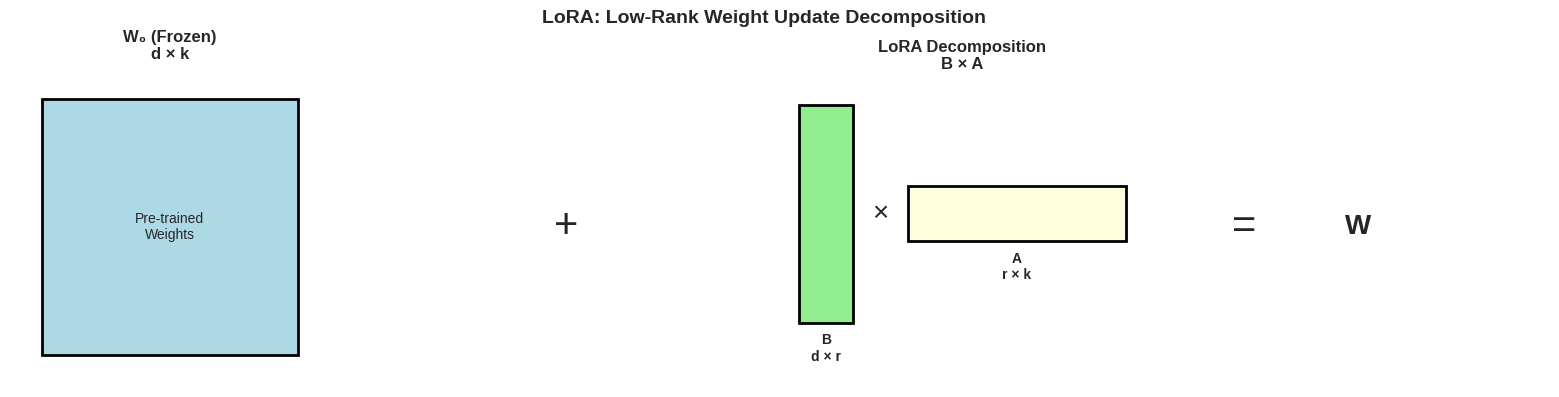

In [3]:
# Cell 4: Visualization of Matrix Decomposition
def visualize_lora_decomposition():
    """Create an interactive visualization of LoRA decomposition"""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Original Weight Matrix W0
    ax = axes[0]
    ax.add_patch(
        Rectangle((0, 0), 4, 4, facecolor="lightblue", edgecolor="black", linewidth=2)
    )
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(-0.5, 4.5)
    ax.set_aspect("equal")
    ax.set_title("W₀ (Frozen)\nd × k", fontsize=12, fontweight="bold")
    ax.text(2, 2, "Pre-trained\nWeights", ha="center", va="center", fontsize=10)
    ax.axis("off")

    # Plus sign
    axes[1].text(0.5, 0.5, "+", fontsize=30, ha="center", va="center")
    axes[1].axis("off")

    # LoRA Matrices
    ax = axes[2]
    # Matrix B
    b_rect = Rectangle(
        (0, 0), 1, 4, facecolor="lightgreen", edgecolor="black", linewidth=2
    )
    ax.add_patch(b_rect)
    ax.text(0.5, -0.7, "B\nd × r", ha="center", fontsize=10, fontweight="bold")

    # Multiplication sign
    ax.text(1.5, 2, "×", fontsize=20, ha="center", va="center")

    # Matrix A
    a_rect = Rectangle(
        (2, 1.5), 4, 1, facecolor="lightyellow", edgecolor="black", linewidth=2
    )
    ax.add_patch(a_rect)
    ax.text(4, 0.8, "A\nr × k", ha="center", fontsize=10, fontweight="bold")

    ax.set_xlim(-0.5, 6.5)
    ax.set_ylim(-1, 4.5)
    ax.set_aspect("equal")
    ax.set_title("LoRA Decomposition\nB × A", fontsize=12, fontweight="bold")
    ax.axis("off")

    # Equals sign
    axes[3].text(0.2, 0.5, "=", fontsize=30, ha="center", va="center")
    axes[3].text(
        0.5, 0.5, "W", fontsize=20, ha="center", va="center", fontweight="bold"
    )
    axes[3].axis("off")

    plt.suptitle(
        "LoRA: Low-Rank Weight Update Decomposition", fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


visualize_lora_decomposition()

In [4]:

class LoRALayer(nn.Module):
    """
    A simple LoRA layer implementation for educational purposes.

    This layer can be applied to any linear transformation.
    """

    def __init__(
        self,
        in_features: int,
        out_features: int,
        rank: int = 8,
        alpha: float = 16.0,
        dropout: float = 0.0,
    ):
        """
        Initialize LoRA layer.

        Args:
            in_features: Input dimension (k)
            out_features: Output dimension (d)
            rank: Low-rank dimension (r)
            alpha: Scaling factor for LoRA updates
            dropout: Dropout probability for LoRA layers
        """
        super().__init__()

        # Store dimensions
        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank  # This is the key scaling factor!

        # Create the original weight matrix (frozen in practice)
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.weight.requires_grad = False  # Freeze original weights

        # Create LoRA parameters
        self.lora_A = nn.Parameter(torch.randn(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))

        # Optional dropout
        self.dropout = nn.Dropout(p=dropout) if dropout > 0 else nn.Identity()

        # Initialize LoRA weights
        self.reset_lora_parameters()

    def reset_lora_parameters(self):
        """Initialize LoRA parameters using Kaiming initialization for A and zeros for B."""
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass with LoRA.

        Args:
            x: Input tensor of shape (batch_size, in_features)

        Returns:
            Output tensor of shape (batch_size, out_features)
        """
        # Original transformation
        result = F.linear(x, self.weight)

        # Add LoRA update: (x @ A^T @ B^T) * scaling
        lora_output = self.dropout(x) @ self.lora_A.T @ self.lora_B.T
        result = result + lora_output * self.scaling

        return result

    def get_merged_weight(self) -> torch.Tensor:
        """Get the effective weight matrix (W0 + ΔW)."""
        delta_w = self.lora_B @ self.lora_A * self.scaling
        return self.weight + delta_w


# Create an example LoRA layer
example_lora = LoRALayer(in_features=512, out_features=256, rank=8, alpha=16)
print(f"Created LoRA layer:")
print(f"  - Input dimension: {example_lora.in_features}")
print(f"  - Output dimension: {example_lora.out_features}")
print(f"  - Rank: {example_lora.rank}")
print(f"  - Alpha: {example_lora.alpha}")
print(f"  - Scaling factor: {example_lora.scaling:.3f}")
print(f"\nParameter count:")
print(f"  - Original weight: {example_lora.weight.numel():,} (frozen)")
print(f"  - LoRA A: {example_lora.lora_A.numel():,}")
print(f"  - LoRA B: {example_lora.lora_B.numel():,}")
print(
    f"  - Total trainable: {example_lora.lora_A.numel() + example_lora.lora_B.numel():,}"
)
print(
    f"  - Reduction: {1 - (example_lora.lora_A.numel() + example_lora.lora_B.numel()) / example_lora.weight.numel():.1%}"
)

Created LoRA layer:
  - Input dimension: 512
  - Output dimension: 256
  - Rank: 8
  - Alpha: 16
  - Scaling factor: 2.000

Parameter count:
  - Original weight: 131,072 (frozen)
  - LoRA A: 4,096
  - LoRA B: 2,048
  - Total trainable: 6,144
  - Reduction: 95.3%


In [5]:
hyperparameter_explanation = """
<div style="background-color: #e8f4f8; color: #000000; padding: 20px; border-radius: 10px; margin: 10px 0;">
    <h3>Rank (r)</h3>
    <p><b>What it is:</b> The dimensionality of the low-rank decomposition</p>
    <p><b>Typical values:</b> 1, 2, 4, 8, 16, 32, 64</p>
    <p><b>Trade-off:</b></p>
    <ul>
        <li>Lower r → Fewer parameters, faster training, less expressive</li>
        <li>Higher r → More parameters, slower training, more expressive</li>
    </ul>
    
    <h3>Alpha (α)</h3>
    <p><b>What it is:</b> A scaling hyperparameter for the LoRA update</p>
    <p><b>Purpose:</b> Controls the magnitude of the LoRA updates relative to the original weights</p>
    <p><b>Scaling formula:</b> <code>scaling_factor = α / r</code></p>
    <p><b>Common practice:</b> Often set α = 2r or α = r</p>
    
    <h3>Why Alpha Matters</h3>
    <ul>
        <li>Stabilizes training when changing rank</li>
        <li>Helps maintain similar learning dynamics across different rank values</li>
        <li>Acts as a "learning rate multiplier" for LoRA updates</li>
    </ul>
</div>
"""

display(HTML(hyperparameter_explanation))

In [6]:
def create_rank_comparison_widget():
    """Create an interactive widget to explore the impact of rank"""

    def update_rank_visualization(rank, dim_in, dim_out):
        clear_output(wait=True)

        # Calculate parameter counts
        original_params = dim_in * dim_out
        lora_params = (dim_in * rank) + (dim_out * rank)
        reduction = 1 - (lora_params / original_params)

        # Create visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Left plot: Matrix dimensions
        ax1.set_xlim(0, 10)
        ax1.set_ylim(0, 10)

        # Original matrix
        orig_width = min(8, dim_in / 100)
        orig_height = min(8, dim_out / 100)
        ax1.add_patch(
            Rectangle(
                (1, 1),
                orig_width,
                orig_height,
                facecolor="lightblue",
                edgecolor="black",
                linewidth=2,
                alpha=0.3,
            )
        )
        ax1.text(
            1 + orig_width / 2, 0.5, f"W₀\n{dim_out}×{dim_in}", ha="center", fontsize=10
        )

        # LoRA matrices
        b_width = min(2, rank / 10)
        b_height = orig_height
        a_width = orig_width
        a_height = min(2, rank / 10)

        # Matrix B
        ax1.add_patch(
            Rectangle(
                (1, 1),
                b_width,
                b_height,
                facecolor="lightgreen",
                edgecolor="black",
                linewidth=2,
            )
        )
        ax1.text(1 + b_width / 2, 0.5, f"B\n{dim_out}×{rank}", ha="center", fontsize=10)

        # Matrix A
        ax1.add_patch(
            Rectangle(
                (1, 9 - a_height),
                a_width,
                a_height,
                facecolor="lightyellow",
                edgecolor="black",
                linewidth=2,
            )
        )
        ax1.text(1 + a_width / 2, 9.5, f"A\n{rank}×{dim_in}", ha="center", fontsize=10)

        ax1.set_title(f"Matrix Decomposition (Rank = {rank})", fontweight="bold")
        ax1.axis("off")

        # Right plot: Parameter comparison
        categories = ["Original\nWeight", "LoRA\nParameters"]
        values = [original_params, lora_params]
        colors = ["lightblue", "lightgreen"]

        bars = ax2.bar(categories, values, color=colors, edgecolor="black", linewidth=2)
        ax2.set_ylabel("Number of Parameters", fontweight="bold")
        ax2.set_title(
            f"Parameter Count Comparison\n({reduction:.1%} reduction)",
            fontweight="bold",
        )

        # Add value labels on bars
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax2.text(
                bar.get_x() + bar.get_width() / 2.0,
                height,
                f"{val:,}",
                ha="center",
                va="bottom",
                fontweight="bold",
            )

        ax2.set_ylim(0, max(values) * 1.2)
        ax2.grid(axis="y", alpha=0.3)

        plt.suptitle(
            f"Impact of Rank on LoRA Architecture", fontsize=14, fontweight="bold"
        )
        plt.tight_layout()
        plt.show()

        # Display statistics
        stats_html = f"""
        <div style="background-color: #f9f9f9; color: #000000; padding: 15px; border-radius: 5px; margin-top: 10px;">
            <h4>Configuration Statistics:</h4>
            <ul>
                <li>Original parameters: <b>{original_params:,}</b></li>
                <li>LoRA parameters: <b>{lora_params:,}</b></li>
                <li>Parameter reduction: <b>{reduction:.1%}</b></li>
                <li>Memory savings: <b>~{reduction:.1%}</b> (approximate)</li>
            </ul>
        </div>
        """
        display(HTML(stats_html))

    # Create interactive widgets
    rank_slider = widgets.IntSlider(
        value=8,
        min=1,
        max=256,
        step=1,
        description="Rank (r):",
        style={"description_width": "initial"},
    )

    dim_in_slider = widgets.IntSlider(
        value=512,
        min=64,
        max=1024,
        step=64,
        description="Input Dim:",
        style={"description_width": "initial"},
    )

    dim_out_slider = widgets.IntSlider(
        value=512,
        min=64,
        max=1024,
        step=64,
        description="Output Dim:",
        style={"description_width": "initial"},
    )

    # Create interactive widget
    interactive_widget = widgets.interactive(
        update_rank_visualization,
        rank=rank_slider,
        dim_in=dim_in_slider,
        dim_out=dim_out_slider,
    )

    display(interactive_widget)


display(HTML("<h1>Explore how rank affects LoRA</h1>"))
create_rank_comparison_widget()

interactive(children=(IntSlider(value=8, description='Rank (r):', max=256, min=1, style=SliderStyle(descriptio…

In [7]:
math_explanation = """
<div style="background-color: #f5f5f5; color: #000000; padding: 20px; border-radius: 10px; margin: 10px 0;">
    <h3>Core Mathematical Concept</h3>
    <p>Given a pre-trained weight matrix <b>W₀ ∈ ℝ^(d×k)</b>, LoRA represents the update as:</p>
    <div style="background-color: white; padding: 10px; border-left: 4px solid #3498db; margin: 10px 0;">
        <code style="font-size: 16px;">W = W₀ + ΔW = W₀ + BA</code>
    </div>
    <p>Where:</p>
    <ul>
        <li><b>W₀</b>: Original frozen weights (d × k)</li>
        <li><b>B</b>: LoRA matrix B (d × r)</li>
        <li><b>A</b>: LoRA matrix A (r × k)</li>
        <li><b>r</b>: Rank (r ≪ min(d, k))</li>
        <li><b>ΔW = BA</b>: Low-rank update</li>
    </ul>
    
    <h3>Why Low-Rank?</h3>
    <p>Instead of updating d × k parameters, we only update (d × r) + (r × k) parameters!</p>
    <p><b>Example:</b> If d=1000, k=1000, r=8:</p>
    <ul>
        <li>Full fine-tuning: 1,000,000 parameters</li>
        <li>LoRA fine-tuning: 16,000 parameters (98.4% reduction!)</li>
    </ul>
</div>
"""

display(HTML(math_explanation))

In [8]:
display(HTML("<h1>Practical Example: Applying LoRA to a Simple Network</h1>"))


class SimpleNetworkWithLoRA(nn.Module):
    """A simple feedforward network with LoRA adaptation"""

    def __init__(
        self, input_dim=784, hidden_dim=256, output_dim=10, lora_rank=8, lora_alpha=16
    ):
        super().__init__()

        # Original layers (would be pre-trained in practice)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

        # Freeze original parameters
        for param in self.fc1.parameters():
            param.requires_grad = False
        for param in self.fc2.parameters():
            param.requires_grad = False

        # Add LoRA adapters
        self.lora1 = LoRALayer(input_dim, hidden_dim, lora_rank, lora_alpha)
        self.lora2 = LoRALayer(hidden_dim, output_dim, lora_rank, lora_alpha)

        self.relu = nn.ReLU()

    def forward(self, x):
        # First layer: original + LoRA
        x = self.fc1(x) + self.lora1(x)
        x = self.relu(x)

        # Second layer: original + LoRA
        x = self.fc2(x) + self.lora2(x)
        return x

    def count_parameters(self):
        """Count trainable and frozen parameters"""
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        frozen = sum(p.numel() for p in self.parameters() if not p.requires_grad)
        return trainable, frozen


# Create the network
model = SimpleNetworkWithLoRA(
    input_dim=784, hidden_dim=256, output_dim=10, lora_rank=8, lora_alpha=16
)

trainable, frozen = model.count_parameters()
total = trainable + frozen

print("Network Architecture:")
print(f"  - Input dimension: 784 (28×28 image)")
print(f"  - Hidden dimension: 256")
print(f"  - Output dimension: 10 (classes)")
print(f"  - LoRA rank: 8")
print(f"  - LoRA alpha: 16")

print(f"\nParameter Statistics:")
print(f"  - Trainable parameters (LoRA): {trainable:,}")
print(f"  - Frozen parameters (original): {frozen:,}")
print(f"  - Total parameters: {total:,}")
print(f"  - Percentage trainable: {100*trainable/total:.2f}%")
print(f"  - Parameter reduction: {100*(1-trainable/frozen):.2f}%")

Network Architecture:
  - Input dimension: 784 (28×28 image)
  - Hidden dimension: 256
  - Output dimension: 10 (classes)
  - LoRA rank: 8
  - LoRA alpha: 16

Parameter Statistics:
  - Trainable parameters (LoRA): 10,448
  - Frozen parameters (original): 406,794
  - Total parameters: 417,242
  - Percentage trainable: 2.50%
  - Parameter reduction: 97.43%


In [9]:
best_practices_html = """
<div style="background-color: #f0fff0; color: #000000; padding: 20px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #2c3e50;">Best Practices for Using LoRA</h2>
    
    <h3>1. Choosing Rank (r)</h3>
    <ul>
        <li><b>Start small:</b> Begin with r=4 or r=8</li>
        <li><b>Task complexity:</b> Simple tasks (r=1-4), Complex tasks (r=8-16)</li>
        <li><b>Model size:</b> Larger models can often use smaller ranks</li>
        <li><b>Validation:</b> Use validation loss to find optimal rank</li>
    </ul>
    
    <h3>2. Setting Alpha (α)</h3>
    <ul>
        <li><b>Common choices:</b> α = r or α = 2r</li>
        <li><b>Stability:</b> Higher α can help with training stability</li>
        <li><b>Fine-tuning:</b> Treat as a hyperparameter to tune</li>
    </ul>
    
    <h3>3. Where to Apply LoRA</h3>
    <ul>
        <li><b>Attention layers:</b> Most common and effective</li>
        <li><b>Query/Value matrices:</b> Often sufficient for good performance</li>
        <li><b>All linear layers:</b> Maximum flexibility but more parameters</li>
    </ul>
    
    <h3>4. Training Tips</h3>
    <ul>
        <li><b>Learning rate:</b> Can often use higher LR than full fine-tuning</li>
        <li><b>Initialization:</b> Kaiming for A, zeros for B (as implemented)</li>
        <li><b>Dropout:</b> Can apply dropout to LoRA layers for regularization</li>
    </ul>
</div>

<div style="background-color: #fff0f0; color: #000000; padding: 20px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #2c3e50;">Common Pitfalls to Avoid</h2>
    <ul>
        <li><b>Rank too high:</b> Defeats the purpose of efficiency</li>
        <li><b>Ignoring alpha:</b> Can lead to unstable training</li>
        <li><b>Wrong initialization:</b> Can slow convergence</li>
    </ul>
</div>
"""

display(HTML(best_practices_html))

## Why Does LoRA Work?

### Hypothesis: Update Matrix ΔW is Low-Rank

During finetuning, the weight update ΔW = W_finetuned - W_pretrained often has low intrinsic rank:
- Pre-trained models already capture rich representations
- Task adaptation requires adjusting in a lower-dimensional subspace
- Empirically verified: full finetuning ΔW has effective rank much lower than full rank

### Mathematical Intuition
If ΔW has effective rank r, then:
- ΔW ≈ UΣV^T where Σ has only r significant singular values
- We can approximate with rank-r decomposition: ΔW ≈ BA
- This is exactly what LoRA does!

## Which Layers to Apply LoRA?

Previously common strategies:
1. **Query & Value projections** (q_proj, v_proj): Most common, good balance
2. **All attention projections** (q, k, v, o): More parameters, better performance
3. **MLP layers**: Sometimes helps, especially for knowledge-intensive tasks

Trade-off: More LoRA layers → Better performance but more parameters


Under some conditions LORA can be equivalent to full fine-tuning. Latest research : https://thinkingmachines.ai/blog/lora/

In [10]:
references_html = """
<div style="background-color: #f9f9f9; color: #000000; padding: 20px; border-radius: 10px;">
    <h3>📚 References</h3>
    <ol>
        <li>Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., ... & Chen, W. (2021). 
            <i>LoRA: Low-Rank Adaptation of Large Language Models.</i> arXiv:2106.09685</li>
        <li>Dettmers, T., Pagnoni, A., Holtzman, A., & Zettlemoyer, L. (2023). 
            <i>QLoRA: Efficient Finetuning of Quantized LLMs.</i> arXiv:2305.14314</li>
        <li>Zhang, Q., Chen, M., Bukharin, A., He, P., Cheng, Y., Chen, W., & Zhao, T. (2023). 
            <i>AdaLoRA: Adaptive Budget Allocation for Parameter-Efficient Fine-Tuning.</i></li>
    </ol>
    
    <h3>🔗 Useful Resources</h3>
    <ul>
        <li>Hugging Face PEFT Library: Implementation of various parameter-efficient methods</li>
        <li>Microsoft LoRA: Official implementation from the authors</li>
    </ul>
</div>
"""

display(HTML(references_html))

# Training tricks

## Training speed up: https://github.com/rasbt/LLMs-from-scratch/tree/main/ch05/10_llm-training-speed

---

## Liger Kernel: https://github.com/linkedin/Liger-Kernel

---

# Distributed training

# What is the difference between data vs tensor vs pipeline vs context parallelism?
# Accelerate N-D Parallel: https://huggingface.co/blog/accelerate-nd-parallel

## What is FSDP? https://pytorch.org/blog/introducing-pytorch-fully-sharded-data-parallel-api/

---

## FSDP 1 vs FSDP 2: https://huggingface.co/docs/accelerate/en/concept_guides/fsdp1_vs_fsdp2

----